# 多层感知机简约实现
过于简约，解释略

In [1]:
import torch
from torch import nn
from d2l import torch as d2l
%run ../my_utils.py

In [2]:
net = nn.Sequential(nn.Flatten(),
                    nn.Linear(784, 256),
                    nn.ReLU(),
                    nn.Linear(256, 10))

def init_weights(m):
    if type(m) == nn.Linear:
        nn.init.normal_(m.weight, std=0.01)

net.apply(init_weights);

In [3]:
batch_size, lr, num_epochs = 256, 0.1, 10
loss = nn.CrossEntropyLoss(reduction='none')
trainer = torch.optim.SGD(net.parameters(), lr=lr)

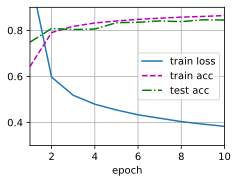

In [4]:
train_iter, test_iter = d2l.load_data_fashion_mnist(batch_size)
train_ch3(net, train_iter, test_iter, loss, num_epochs, trainer)

## 改变参数


### batch_size 更改
1. 减小batch_size

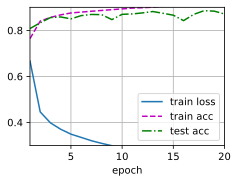

In [5]:
net.apply(init_weights);
batch_size, lr, num_epochs = 64, 0.1, 20
loss = nn.CrossEntropyLoss(reduction='none')
trainer = torch.optim.SGD(net.parameters(), lr=lr)
train_iter, test_iter = d2l.load_data_fashion_mnist(batch_size)
train_ch3(net, train_iter, test_iter, loss, num_epochs, trainer)

2. 增大batch_size

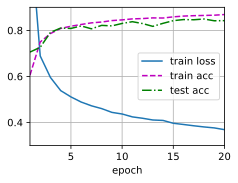

In [6]:
net.apply(init_weights);
batch_size, lr, num_epochs = 512, 0.1, 20
loss = nn.CrossEntropyLoss(reduction='none')
trainer = torch.optim.SGD(net.parameters(), lr=lr)
train_iter, test_iter = d2l.load_data_fashion_mnist(batch_size)
train_ch3(net, train_iter, test_iter, loss, num_epochs, trainer)

发现小batch情况下训练效果更好，推断可能原因如下：
1. 同样数据量下，小batch参数更新次数更多，相当于训练更细
2. batch_size = 64可能更适合当前学习率：batch_size 愈大，梯度越接近真实梯度，方向稳定，方差减小，需要更大的学习率；反之则梯度越大，需要减小学习率。由此可以推断课件代码中学习率应该偏小

### 改变层数与层大小
1. 增大层大小

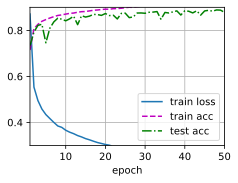

In [7]:
net = nn.Sequential(nn.Flatten(),
                    nn.Linear(784, 2048),
                    nn.ReLU(),
                    nn.Linear(2048, 10))
net.apply(init_weights);
batch_size, lr, num_epochs = 256, 0.1, 50
loss = nn.CrossEntropyLoss(reduction='none')
trainer = torch.optim.SGD(net.parameters(), lr=lr)
train_iter, test_iter = d2l.load_data_fashion_mnist(batch_size)
train_ch3(net, train_iter, test_iter, loss, num_epochs, trainer)

2. 增加深度

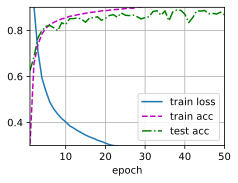

In [8]:
net = nn.Sequential(
    nn.Flatten(),
    nn.Linear(784, 256),
    nn.ReLU(),
    nn.Linear(256, 128),
    nn.ReLU(),
    nn.Linear(128, 10)
)
net.apply(init_weights);
batch_size, lr, num_epochs = 256, 0.1, 50
loss = nn.CrossEntropyLoss(reduction='none')
trainer = torch.optim.SGD(net.parameters(), lr=lr)
train_iter, test_iter = d2l.load_data_fashion_mnist(batch_size)
train_ch3(net, train_iter, test_iter, loss, num_epochs, trainer)

3. 再增加

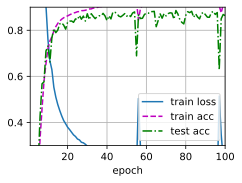

In [9]:
net = nn.Sequential(
    nn.Flatten(),
    nn.Linear(784, 128),
    nn.ReLU(),
    nn.Linear(128, 64),
    nn.ReLU(),
    nn.Linear(64, 32),
    nn.ReLU(),
    nn.Linear(32, 10)
)
net.apply(init_weights);
batch_size, lr, num_epochs = 256, 0.1, 100
loss = nn.CrossEntropyLoss(reduction='none')
trainer = torch.optim.SGD(net.parameters(), lr=lr)
train_iter, test_iter = d2l.load_data_fashion_mnist(batch_size)
train_ch3(net, train_iter, test_iter, loss, num_epochs, trainer)

4. 隐藏层大小相同

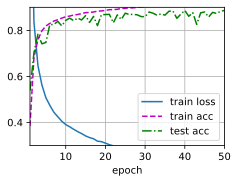

In [10]:
net = nn.Sequential(
    nn.Flatten(),
    nn.Linear(784, 256),
    nn.ReLU(),
    nn.Linear(256, 256),
    nn.ReLU(),
    nn.Linear(256, 10)
)
net.apply(init_weights);
batch_size, lr, num_epochs = 256, 0.1, 50
loss = nn.CrossEntropyLoss(reduction='none')
trainer = torch.optim.SGD(net.parameters(), lr=lr)
train_iter, test_iter = d2l.load_data_fashion_mnist(batch_size)
train_ch3(net, train_iter, test_iter, loss, num_epochs, trainer)

总结发现：
1. 深度和层大小增加都能降低training loss, 同时训练时间增加。
2. 深度提高时loss在初期会非常大，训练函数中不能使用assert loss < 0.5，本次通过注释掉这行代码解决。
3. 深度过大在多轮训练后反而出现模型性能大幅下降，可能过拟合